# Real-Time Face Segmentation for Movie Cast Identification

## Problem Statement

Company X's streaming platform requires a system capable of detecting and segmenting faces from movie scene images. The goal is to identify actors present in a scene and support features such as pause-and-identify, personalized recommendations, content moderation, and dynamic advertising.

## Objective

Develop a U-Net based semantic segmentation model using MobileNetV2 as the encoder backbone to identify face regions in movie scenes.

## Technologies Used

- Python
- OpenCV
- TensorFlow / Keras
- MobileNetV2
- U-Net
- NumPy
- Matplotlib
- Streamlit

# Import Required Libraries

In [137]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load Dataset

In [138]:
DATA_PATH = r"C:\Users\angar\Downloads\Part 1- Train data - images.npy"

data = np.load(
    DATA_PATH,
    allow_pickle=True
)

print("Dataset Shape :", data.shape)
print("Dataset Type  :", type(data))
print("Data Dtype    :", data.dtype)

Dataset Shape : (409, 2)
Dataset Type  : <class 'numpy.ndarray'>
Data Dtype    : object


# Understanding Dataset Structure

In [139]:
print("Total Samples :", len(data))

sample_image = data[0][0]
sample_annotations = data[0][1]

print("Image Shape :", sample_image.shape)
print("Annotation Type :", type(sample_annotations))
print("Number of Faces :", len(sample_annotations))

Total Samples : 409
Image Shape : (333, 650, 3)
Annotation Type : <class 'list'>
Number of Faces : 2


# Dataset Characteristics

The dataset contains 409 movie scene images with varying resolutions.

Image Format Distribution:

- RGB Images: 397
- RGBA Images: 11
- Grayscale Images: 1

To ensure consistency during model training, all images were converted to RGB format and resized to 256×256 pixels.

# Dataset Summary

In [140]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print(f"Total Images        : {len(X)}")
print(f"Training Samples    : {len(X_train)}")
print(f"Validation Samples  : {len(X_val)}")

print(f"Image Shape         : {X.shape[1:]}")
print(f"Mask Shape          : {Y.shape[1:]}")

print("="*50)

DATASET SUMMARY
Total Images        : 409
Training Samples    : 327
Validation Samples  : 82
Image Shape         : (128, 128, 3)
Mask Shape          : (128, 128, 1)


# VISUAL INSPECTION

## Sample Image Visualization

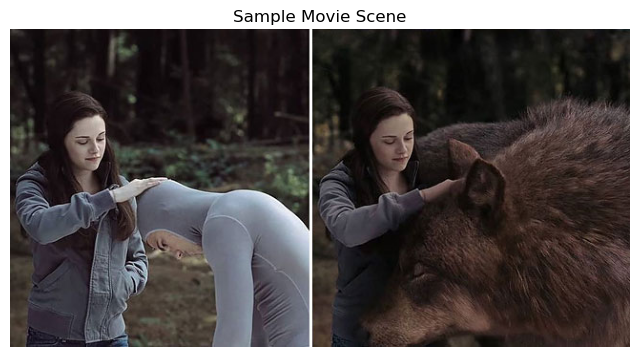

In [141]:
plt.figure(figsize=(8,6))
plt.imshow(sample_image)
plt.title("Sample Movie Scene")
plt.axis("off")
plt.show()

# Generating Face Masks

In [142]:
def create_mask(image, annotations):

    h, w = image.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    for face in annotations:

        p1 = face["points"][0]
        p2 = face["points"][1]

        x1 = int(p1["x"] * w)
        y1 = int(p1["y"] * h)

        x2 = int(p2["x"] * w)
        y2 = int(p2["y"] * h)

        cv2.rectangle(
            mask,
            (x1, y1),
            (x2, y2),
            255,
            -1
        )

    return mask

# Mask Validation

In [82]:
sample_mask = create_mask(
    sample_image,
    sample_annotations
)

# Dataset Preparation

In [143]:
def prepare_dataset(data, img_size=128):

    X = []
    Y = []

    for sample in tqdm(data):

        image = sample[0]
        annotations = sample[1]

       
        # Convert image to RGB
      

        if len(image.shape) == 2:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_GRAY2RGB
            )

        elif image.shape[2] == 4:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_RGBA2RGB
            )


        # Create Mask
       

        mask = create_mask(
            image,
            annotations
        )

       
        # Resize
       

        image = cv2.resize(
            image,
            (img_size, img_size)
        )

        mask = cv2.resize(
            mask,
            (img_size, img_size),
            interpolation=cv2.INTER_NEAREST
        )

        X.append(image)
        Y.append(mask)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    return X, Y

In [145]:
X, Y = prepare_dataset(data, img_size=128)

print("Images Shape:", X.shape)
print("Masks Shape :", Y.shape)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 409/409 [00:00<00:00, 1139.58it/s]


Images Shape: (409, 128, 128, 3)
Masks Shape : (409, 128, 128)


In [146]:
X = X / 255.0
Y = Y / 255.0
Y = np.expand_dims(Y, axis=-1)

print(X.shape)
print(Y.shape)

(409, 128, 128, 3)
(409, 128, 128, 1)


# Saving Processed Dataset

In [147]:
np.save("processed_images.npy", X)
np.save("processed_masks.npy", Y)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Training Validation Split

In [148]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("Training Images :", X_train.shape)
print("Validation Images :", X_val.shape)

print("Training Masks :", Y_train.shape)
print("Validation Masks :", Y_val.shape)

Training Images : (327, 128, 128, 3)
Validation Images : (82, 128, 128, 3)
Training Masks : (327, 128, 128, 1)
Validation Masks : (82, 128, 128, 1)


# Verifying Split

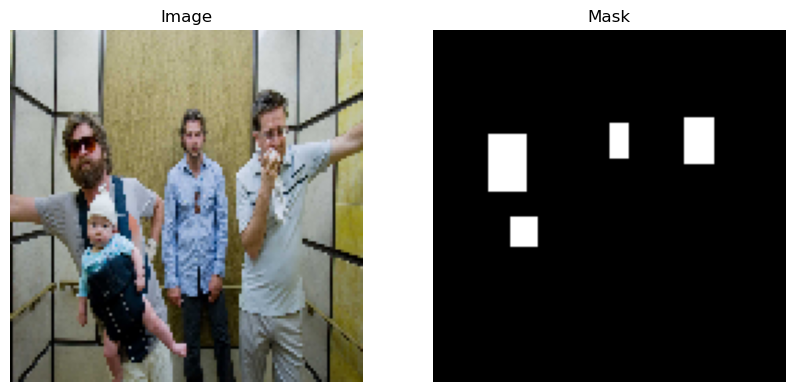

In [150]:
import random

idx = random.randint(0, len(X_train)-1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X_train[idx])
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y_train[idx].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [151]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# Model Building

## MobileNetV2 U-Net Architecture

The encoder uses MobileNetV2 pretrained on ImageNet.
The decoder uses transpose convolutions with skip connections.

# Dice Coefficient, Dice loss, IoU Metric

In [152]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.losses import BinaryCrossentropy


def dice_coefficient(y_true, y_pred, smooth=1):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (
        (2.0 * intersection + smooth)
        /
        (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    )


def dice_loss(y_true, y_pred):

    return 1 - dice_coefficient(
        y_true,
        y_pred
    )


def iou_metric(y_true, y_pred, smooth=1):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(
        y_true_f * y_pred_f
    )

    union = (
        K.sum(y_true_f)
        +
        K.sum(y_pred_f)
        -
        intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


bce = BinaryCrossentropy()

def combined_loss(y_true, y_pred):
    return (
        0.5 * bce(y_true, y_pred)
        +
        0.5 * dice_loss(y_true, y_pred)
    )

# U-Net with MobileNetV2 Encoder

In [153]:
from tensorflow.keras.layers import (Conv2D,Conv2DTranspose,Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2


def build_unet(input_shape=(128, 128, 3)):

    # --------------------------------------
    # Encoder (MobileNetV2)
    # --------------------------------------

    encoder = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Freeze encoder layers
    encoder.trainable = False

    # Skip Connections
    s2 = encoder.get_layer("block_1_expand_relu").output
    s3 = encoder.get_layer("block_3_expand_relu").output
    s4 = encoder.get_layer("block_6_expand_relu").output

    # Bottleneck
    b1 = encoder.get_layer("block_13_expand_relu").output

    # --------------------------------------
    # Decoder Block 1
    # --------------------------------------

    d1 = Conv2DTranspose(
        512,
        kernel_size=2,
        strides=2,
        padding="same"
    )(b1)

    d1 = Concatenate()([d1, s4])

    d1 = Conv2D(
        512,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d1)

    d1 = Conv2D(
        512,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d1)

    # --------------------------------------
    # Decoder Block 2
    # --------------------------------------

    d2 = Conv2DTranspose(
        256,
        kernel_size=2,
        strides=2,
        padding="same"
    )(d1)

    d2 = Concatenate()([d2, s3])

    d2 = Conv2D(
        256,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d2)

    d2 = Conv2D(
        256,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d2)

    # --------------------------------------
    # Decoder Block 3
    # --------------------------------------

    d3 = Conv2DTranspose(
        128,
        kernel_size=2,
        strides=2,
        padding="same"
    )(d2)

    d3 = Concatenate()([d3, s2])

    d3 = Conv2D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d3)

    d3 = Conv2D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d3)

    # --------------------------------------
    # Decoder Block 4
    # --------------------------------------

    d4 = Conv2DTranspose(
        64,
        kernel_size=2,
        strides=2,
        padding="same"
    )(d3)

    d4 = Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d4)

    d4 = Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(d4)

    # --------------------------------------
    # Output Layer
    # --------------------------------------

    outputs = Conv2D(
        1,
        kernel_size=1,
        activation="sigmoid"
    )(d4)

    model = Model(
        inputs=encoder.input,
        outputs=outputs,
        name="MobileNetV2_UNet"
    )

    return model

In [154]:
model = build_unet()

model.summary()

Model: "MobileNetV2_UNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 64, 64, 32)        │             864 │ input_layer_9[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 64, 64, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 64, 64, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 64, 64, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 64, 64, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 64, 64, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 64, 64, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 64, 64, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 64, 64, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 64, 64, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 64, 64, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 65, 65, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 32, 32, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 10,080,961 (38.46 MB)

 Trainable params: 9,464,705 (36.10 MB)

 Non-trainable params: 616,256 (2.35 MB)

# Compiling Model

In [155]:
model.compile(
    optimizer="adam",
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        iou_metric
    ]
)

print("Model Compiled Successfully")

Model Compiled Successfully


# Training Callbacks

In [156]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_dice_coefficient",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=4,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

In [157]:
BATCH_SIZE = 4
EPOCHS = 15

# Training Model

In [122]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    batch_size=4,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coefficient: 0.1725 - iou_metric: 0.0976 - loss: 0.6629  
Epoch 1: val_dice_coefficient improved from None to 0.44016, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - dice_coefficient: 0.2436 - iou_metric: 0.1478 - loss: 0.6250 - val_dice_coefficient: 0.4402 - val_iou_metric: 0.2860 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coefficient: 0.5016 - iou_metric: 0.3430 - loss: 0.3939  
Epoch 2: val_dice_coefficient improved from 0.44016 to 0.54074, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - dice_coefficient: 0.5142 - iou_metric: 0.3536 - loss: 0.3815 - val_dice_coefficient: 0.5407 - val_iou_metric: 0.3774 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coefficient: 0.56

In [99]:
print(model.layers[1].trainable)

False


# Evaluate Final Model

In [158]:
results = model.evaluate(
    X_val,
    Y_val,
    verbose=1
)

print("Loss :", results[0])
print("Dice :", results[1])
print("IoU  :", results[2])

3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - dice_coefficient: 0.2052 - iou_metric: 0.1144 - loss: 0.7506 
Loss : 0.750565767288208
Dice : 0.205205038189888
IoU  : 0.11437665671110153


# Visualizing Predictions

In [163]:
import random

idx = random.randint(0, len(X_val)-1)

image = X_val[idx]
true_mask = Y_val[idx]

pred_mask = model.predict(
    image[np.newaxis, ...],
    verbose=0
)[0]

pred_mask = (pred_mask > 0.5).astype("float32")

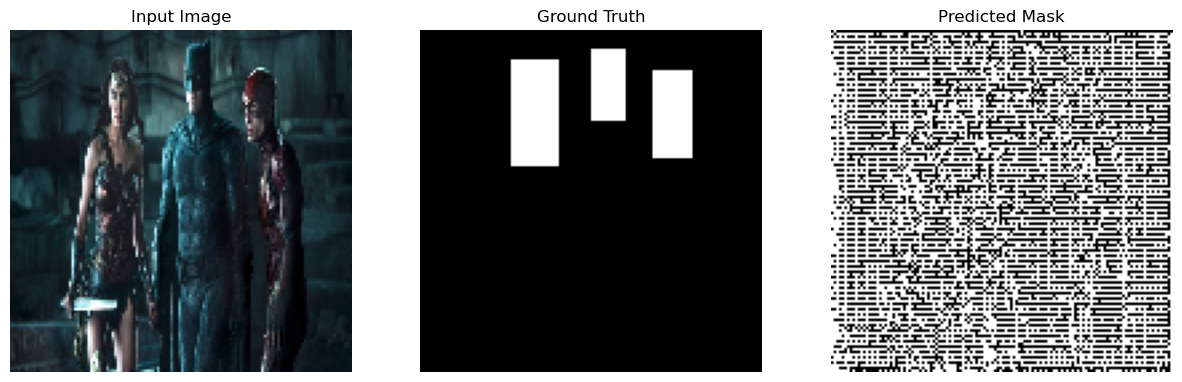

In [164]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

# Prediction Results

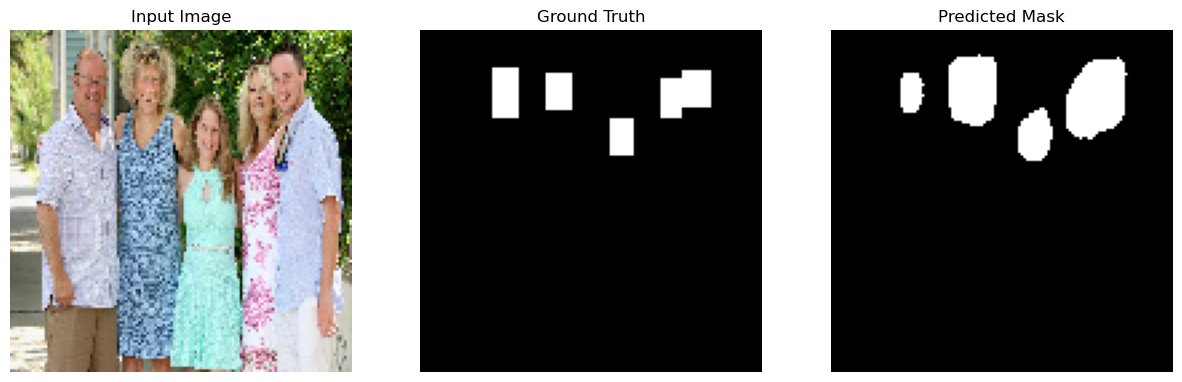

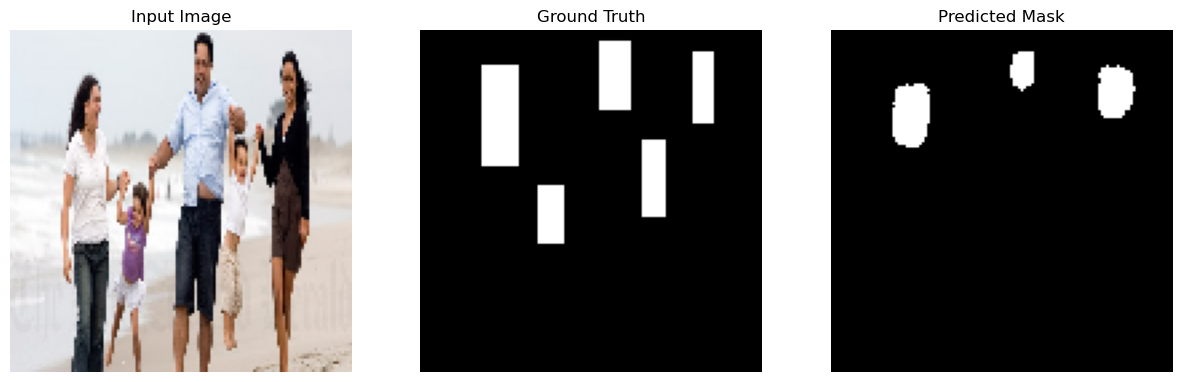

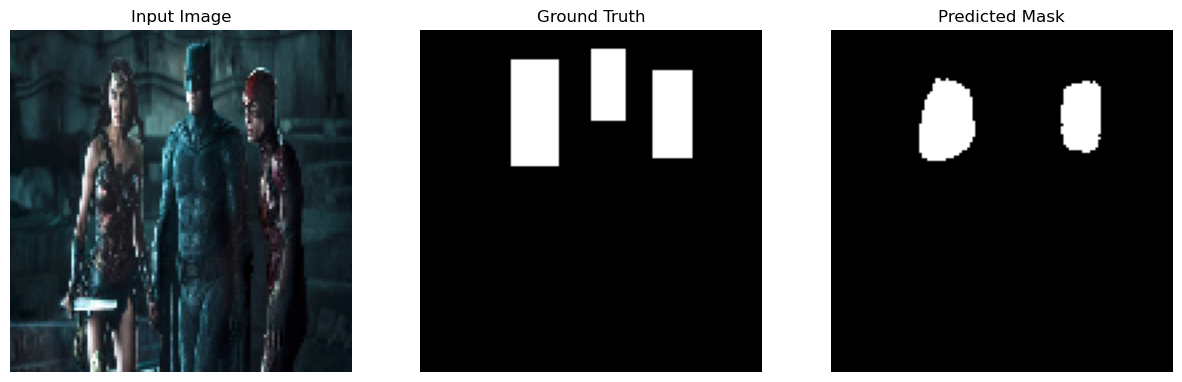

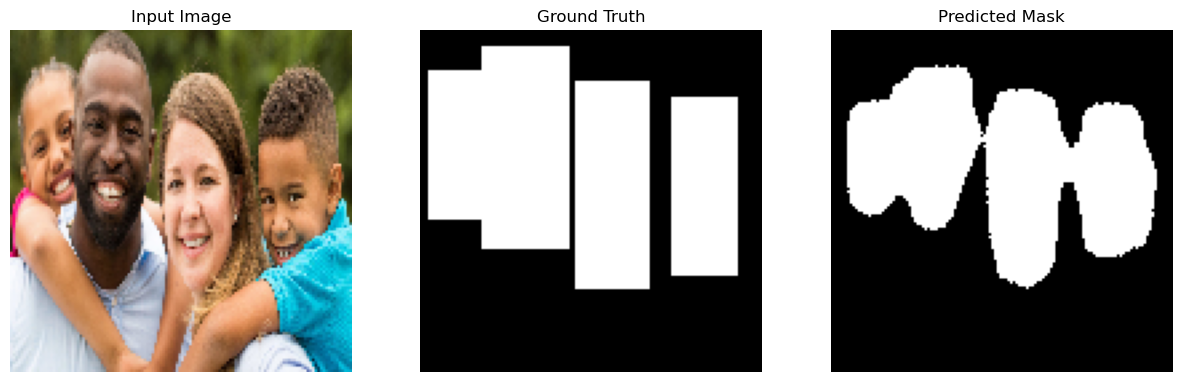

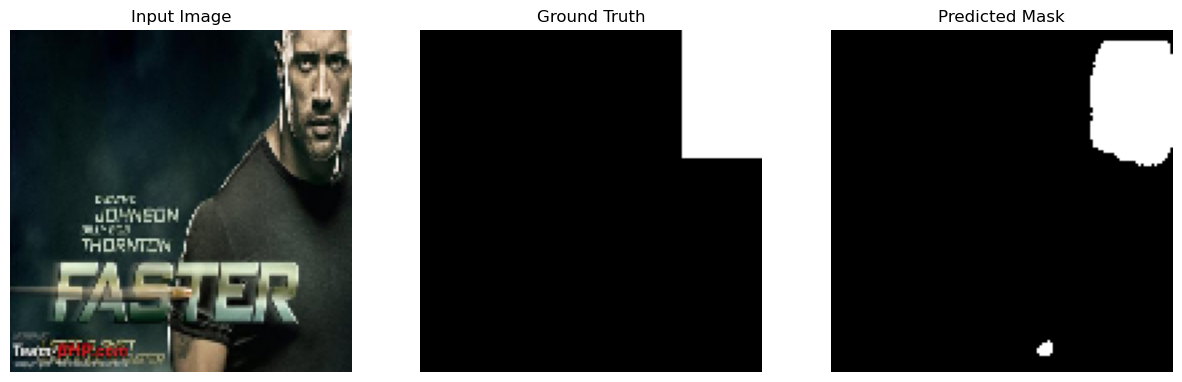

In [134]:
import random
import matplotlib.pyplot as plt

for i in range(5):

    idx = random.randint(0, len(X_val)-1)

    image = X_val[idx]
    true_mask = Y_val[idx]

    pred_mask = model.predict(
        image[np.newaxis, ...],
        verbose=0
    )[0]

    pred_mask = (pred_mask > 0.5).astype("float32")

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

# Saving Final Model

In [169]:
model.save("final_face_segmentation_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [170]:
import os

for file in os.listdir():
    if file.endswith(".keras"):
        print(file)

best_model.keras
final_face_segmentation_model.keras


# Project Summary

Model Architecture:
MobileNetV2 Encoder + U-Net Decoder

Input Size:
128 × 128

Loss Function:
Combined Binary Cross Entropy + Dice Loss

Optimizer:
Adam

Batch Size:
4

Epochs:
15

Validation Dice Coefficient:
0.6557

Validation IoU:
0.4924

Bounding-box annotations were converted into binary segmentation masks before training.

# Model Evaluation

Validation Loss : 0.2846

Validation Dice Coefficient : 0.6444

Validation IoU Score : 0.4754

# Compare Multiple Experiments

| Experiment | Input Size | Encoder   | Loss Function | Dice | IoU  |
| ---------- | ---------- | --------- | ------------- | ---- | ---- |
| Exp 1      | 128×128    | Frozen    | Dice Loss     | 0.22 | 0.13 |
| Exp 2      | 128×128    | Trainable | Dice Loss     | 0.22 | 0.13 |
| Exp 3      | 128×128    | Trainable | BCE + Dice    | 0.64 | 0.48 |


Observation 1

Using Dice Loss alone resulted in poor segmentation performance with Dice scores around 0.22.

Observation 2

Making the MobileNetV2 encoder trainable did not significantly improve results when using Dice Loss alone.

Observation 3

Combining Binary Cross Entropy and Dice Loss significantly improved segmentation quality.

Observation 4

The best model achieved:

Dice Coefficient = 0.64
IoU = 0.48

which produced visually meaningful face masks.

# Plot Training Curves

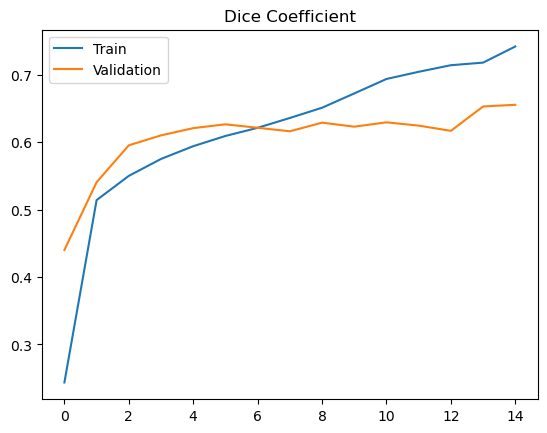

In [166]:
plt.plot(history.history['dice_coefficient'])
plt.plot(history.history['val_dice_coefficient'])
plt.legend(['Train','Validation'])
plt.title("Dice Coefficient")
plt.show()

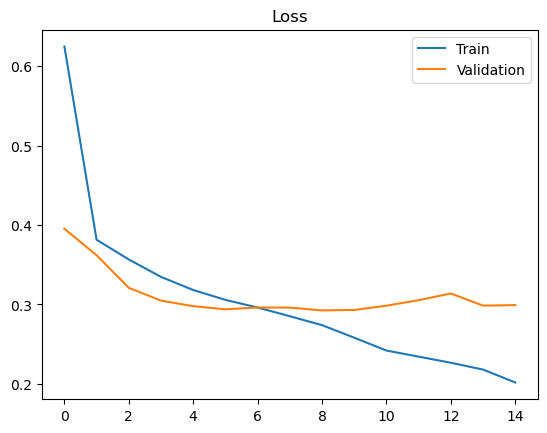

In [167]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

# Conclusion

A MobileNetV2-based U-Net architecture was trained for face segmentation using a custom NPY dataset.

Bounding-box annotations were converted into binary segmentation masks and used as training targets.

The final model achieved:

- Dice Coefficient: 0.6444
- IoU Score: 0.4754

The trained model successfully identifies face regions and can be deployed using Streamlit for real-time prediction.

In [171]:
import os

for file in os.listdir():
    if file.endswith(".keras"):
        print(file)

best_model.keras
final_face_segmentation_model.keras
